# Text Classification — Few-Shot with Groq


In [1]:
import os
import time
import random
from pathlib import Path
import pandas as pd
from tqdm import tqdm
from groq import Groq
from difflib import get_close_matches

try:
    from dotenv import load_dotenv
except ImportError:
    load_dotenv = None

env_candidates = [
    Path(".env"),
    Path("shot") / ".env",
]
loaded = False
for env_path in env_candidates:
    if env_path.exists():
        if load_dotenv is not None:
            load_dotenv(env_path)
        else:
            for line in env_path.read_text(encoding="utf-8").splitlines():
                line = line.strip()
                if not line or line.startswith("#") or "=" not in line:
                    continue
                k, v = line.split("=", 1)
                os.environ[k.strip()] = v.strip().strip('"').strip("'")
        print(f"Loaded .env from: {env_path.resolve()}")
        loaded = True
        break
if not loaded:
    print("No .env file found in expected paths (.env, shot/.env).")

# -- CONFIG -----------------------------------------------------------------
GROQ_API_KEY = os.getenv("GROQ_API_KEY", "")
MODEL = "llama-3.3-70b-versatile"
K_SHOTS = 3
SLEEP_SEC = 1.2
RANDOM_SEED = 808815
# ---------------------------------------------------------------------------

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY not found. Add it to .env in this folder (or shot/.env).")

random.seed(RANDOM_SEED)
client = Groq(api_key=GROQ_API_KEY)
print("Groq client ready")

Loaded .env from: C:\Users\bruno\Desktop\um_ucs_mestrado\deep_learning\projeto\shot\.env
Groq client ready


## 1. Load Data


In [2]:
# -- Labeled training data ---------------------------------------------------
# Expected columns: ID, Text, Label (adjust if column names differ)

TRAIN_FILES = {
    "train1": "subm1_labels_revealed.csv",
    "train2": "subm2_labels_revealed.csv",
}

train_dfs = {}
for name, path in TRAIN_FILES.items():
    train_df_ = pd.read_csv(path, sep=";", encoding="utf-8-sig")
    train_dfs[name] = train_df_
    print(f"{name}: {len(train_df_)} rows")

train_df = pd.concat(train_dfs.values(), ignore_index=True)
print(f"\nTotal training rows: {len(train_df)}")

train1: 100 rows
train2: 100 rows

Total training rows: 200


In [6]:
# ── Adjust paths to your files ──────────────────────────────────────────────
FILES = {

    "subm3": "subm3.csv",
}

dfs = {}
for name, path in FILES.items():
    df = pd.read_csv(path, sep=";", encoding="utf-8-sig")
    dfs[name] = df
    print(f"{name}: {len(df)} rows — columns: {list(df.columns)}")

# Combine all into one DataFrame for batch processing
all_df = pd.concat(dfs.values(), ignore_index=True)
print(f"\nTotal rows: {len(all_df)}")
all_df.head()

subm3: 150 rows — columns: ['ID', 'Text']

Total rows: 150


,ID,Text
0,D2-126,The reality about the places that diamonds are...
1,D2-127,Geothermobarometric calculations for a worldwi...
2,D2-128,Diamonds are formed deep within the Earth’s ma...
3,D2-129,Diamond is a solid form of the element carbon ...
4,D2-130,Diamonds are formed deep within the Earth unde...


## 2. Build Examples Pool


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

train_df["Text"] = train_df["Text"].fillna("").astype(str)
train_df["Label"] = train_df["Label"].astype(str).str.strip()
LABELS = sorted(train_df["Label"].dropna().unique().tolist())
VALID_LABELS_LOWER = {l.lower(): l for l in LABELS}
print(f"All labels ({len(LABELS)}): {LABELS[:10]} ...")

print("Building TF-IDF index over training set...")
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
train_tfidf = vectorizer.fit_transform(train_df["Text"])
print(f"TF-IDF matrix: {train_tfidf.shape}")

All labels (5): ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI'] ...
Building TF-IDF index over training set...
TF-IDF matrix: (200, 10000)


In [7]:
def get_similar_examples(query_text: str, k: int = K_SHOTS) -> list[dict]:
    """
    Retrieve k training examples that are most similar to the query text.
    Returns a list of dicts with 'text' and 'label' keys.
    """
    query_text = "" if query_text is None else str(query_text)
    query_vec = vectorizer.transform([query_text])
    sims = cosine_similarity(query_vec, train_tfidf).flatten()
    top_k_idx = sims.argsort()[::-1][:k]

    examples = []
    for idx in top_k_idx:
        row = train_df.iloc[idx]
        examples.append({"text": row["Text"], "label": row["Label"]})
    return examples


# Fallback: random examples when TF-IDF is not available or for diversity
def get_random_examples(k: int = K_SHOTS) -> list[dict]:
    """Sample k random training examples, one per label for diversity."""
    sampled = train_df.groupby("Label").apply(
        lambda g: g.sample(1, random_state=RANDOM_SEED)
    ).sample(min(k, len(LABELS)), random_state=RANDOM_SEED)
    return [{"text": r["Text"], "label": r["Label"]} for _, r in sampled.iterrows()]


# Test retrieval
test_query = all_df["Text"].iloc[0]
examples = get_similar_examples(test_query)
print("Examples retrieved for first query:")
for i, ex in enumerate(examples, 1):
    print(f"  {i}. [{ex['label']}] {ex['text'][:100]}...")

Examples retrieved for first query:
  1. [Meta] Diamonds are formed through a natural geological process that involves high pressure and temperature...
  2. [Google] Diamonds, those captivating gemstones, are forged under truly extreme conditions deep within the Ear...
  3. [Human] High-pressure areas form due to downward motion through the troposphere, the atmospheric layer where...


## 3. Few-Shot Classification Function

In [8]:
LABELS_STR = "\n".join(f"- {l}" for l in LABELS)

SYSTEM_PROMPT = """You are a precise text classification assistant.
Classify each text into exactly one label from the provided label list.
Use only labels from the list and output only the label name (no extra text)."""


def format_examples(examples: list[dict]) -> str:
    """Format retrieved examples for inclusion in the prompt."""
    parts = []
    for i, ex in enumerate(examples, 1):
        parts.append(
            f"Example {i}:\n"
            f"Text: \"{str(ex['text'])[:500]}\"\n"
            f"Label: {str(ex['label']).strip()}"
        )
    return "\n\n".join(parts)


def normalize_pred_label(pred: str) -> str:
    pred_clean = str(pred).strip().strip('"\'`').rstrip(".,;:").strip()
    return VALID_LABELS_LOWER.get(pred_clean.lower(), pred_clean)


def classify_few_shot(text: str, use_similarity: bool = True) -> str:
    """Classify a single text using few-shot prompting."""
    text = "" if text is None else str(text)

    if use_similarity:
        examples = get_similar_examples(text, k=K_SHOTS)
    else:
        examples = get_random_examples(k=K_SHOTS)

    examples_str = format_examples(examples)

    user_prompt = f"""Valid labels:

{LABELS_STR}

Labeled examples:

{examples_str}

Text to classify:
\"\"\"
{text[:3000]}
\"\"\"

Return exactly one label from the valid labels list."""

    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt},
        ],
        temperature=0,
        max_tokens=20,
    )
    raw = response.choices[0].message.content
    return normalize_pred_label(raw)


# Quick test
print("Test prediction:", classify_few_shot(all_df["Text"].iloc[0]))

Test prediction: OpenAI


## 4. Run Inference on All Rows

In [8]:
predictions = []
errors      = []

for idx, row in tqdm(all_df.iterrows(), total=len(all_df), desc="Classifying (few-shot)"):
    try:
        label = classify_few_shot(row["Text"], use_similarity=True)
        predictions.append({"ID": row["ID"], "Label": label})
    except Exception as e:
        print(f"Error on ID {row['ID']}: {e}")
        errors.append(row["ID"])
        predictions.append({"ID": row["ID"], "Label": "ERROR"})
    time.sleep(SLEEP_SEC)

print(f"\nDone. Errors: {len(errors)}")

Classifying (few-shot): 100%|██████████| 150/150 [07:49<00:00,  3.13s/it]


Done. Errors: 0


## 5. Post-process: Snap to Closest Valid Label

In [12]:
results_df = pd.DataFrame(predictions)

def snap_label(pred: str, valid_labels: list, cutoff: float = 0.6) -> str:
    pred = normalize_pred_label(pred)
    if pred in valid_labels:
        return pred
    matches = get_close_matches(pred, valid_labels, n=1, cutoff=cutoff)
    return matches[0] if matches else pred

results_df["Label_snapped"] = results_df["Label"].apply(
    lambda x: snap_label(x, LABELS)
)

corrections = results_df[results_df["Label"] != results_df["Label_snapped"]]
print(f"Corrections made: {len(corrections)}")
corrections[["ID", "Label", "Label_snapped"]].head(10)

NameError: name 'predictions' is not defined

## 6. Save Submissions

In [ ]:
final_df = results_df[["ID", "Label_snapped"]].rename(columns={"Label_snapped": "Label"})

out_path = "sub3-g5-MECD-A.csv"
final_df.to_csv(out_path, sep=";", index=False)
print(f"Saved {len(final_df)} rows -> {out_path}")

final_df.head(10)

Saved 150 rows -> submission_fewshot_all.csv


,ID,Label
0,D2-126,OpenAI
1,D2-127,Meta
2,D2-128,OpenAI
3,D2-129,OpenAI
4,D2-130,Meta
5,D2-131,Meta
6,D2-132,Human
7,D2-133,Meta
8,D2-134,Meta
9,D2-135,Meta



## Evaluation on `data-exemplo.csv`


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# -- Load labeled evaluation set ---------------------------------------------
EVAL_CANDIDATES = ["dataset-exemplos.csv", "data-exemplo.csv"]
eval_path = next((p for p in EVAL_CANDIDATES if os.path.exists(p)), None)
if eval_path is None:
    raise FileNotFoundError(f"Could not find any eval file in: {EVAL_CANDIDATES}")

eval_df = pd.read_csv(eval_path, sep=";", encoding="utf-8-sig")
print(f"Evaluation file: {eval_path}")
print(f"Evaluation set: {len(eval_df)} rows")
print(f"Columns: {list(eval_df.columns)}")

# Auto-detect label column name
label_col = next(
    (c for c in eval_df.columns if c.lower() in ["label", "topic", "class", "category"]),
    eval_df.columns[-1],
)
print(f"Using '{label_col}' as the label column")
print(f"Unique true labels: {eval_df[label_col].nunique()}")
eval_df.head()

Evaluation file: dataset-exemplos.csv
Evaluation set: 125 rows
Columns: ['ID', 'Text', 'Label']
Using 'Label' as the label column
Unique true labels: 5


,ID,Text,Label
0,D1-1,"It is an approximation useful in chemistry, bu...",Human
1,D1-2,"PET scanning, or Positron Emission Tomography,...",Meta
2,D1-3,Positron Emission Tomography (PET) scanning is...,Google
3,D1-4,Thermonuclear fusion is the process of combini...,Meta
4,D1-5,"These nutrients are needed to keep bones, teet...",Human


In [ ]:

eval_predictions = []
eval_errors      = []

for idx, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="Evaluating (few-shot)"):
    try:
        label = classify_few_shot(row["Text"], use_similarity=True)
        eval_predictions.append({"ID": row["ID"], "Pred": label, "True": row[label_col]})
    except Exception as e:
        print(f"Error on ID {row['ID']}: {e}")
        eval_errors.append(row["ID"])
        eval_predictions.append({"ID": row["ID"], "Pred": "ERROR", "True": row[label_col]})
    time.sleep(SLEEP_SEC)

print(f"\n Evaluation done. Errors: {len(eval_errors)}")
eval_results = pd.DataFrame(eval_predictions)

Evaluating (few-shot): 100%|██████████| 125/125 [06:15<00:00,  3.00s/it]


✅ Evaluation done. Errors: 0


In [14]:
def snap_label(pred: str, valid_labels: list, cutoff: float = 0.6) -> str:
    pred = normalize_pred_label(pred)
    if pred in valid_labels:
        return pred
    matches = get_close_matches(pred, valid_labels, n=1, cutoff=cutoff)
    return matches[0] if matches else pred



In [15]:
# ── Snap to valid labels & score ─────────────────────────────────────────────
eval_results["Pred_snapped"] = eval_results["Pred"].apply(
    lambda x: snap_label(x, LABELS)
)

y_true = eval_results["True"].tolist()
y_pred = eval_results["Pred_snapped"].tolist()

acc = accuracy_score(y_true, y_pred)
print(f"\n{'='*50}")
print(f"  Few-Shot Accuracy: {acc:.2%}  ({int(acc*len(y_true))}/{len(y_true)} correct)")
print(f"{'='*50}\n")

print(classification_report(y_true, y_pred, zero_division=0))


  Few-Shot Accuracy: 47.20%  (59/125 correct)

              precision    recall  f1-score   support

   Anthropic       0.56      0.22      0.31        23
      Google       0.29      0.12      0.17        16
       Human       0.72      0.69      0.71        52
        Meta       0.24      0.41      0.30        17
      OpenAI       0.30      0.53      0.38        17

    accuracy                           0.47       125
   macro avg       0.42      0.40      0.38       125
weighted avg       0.51      0.47      0.47       125



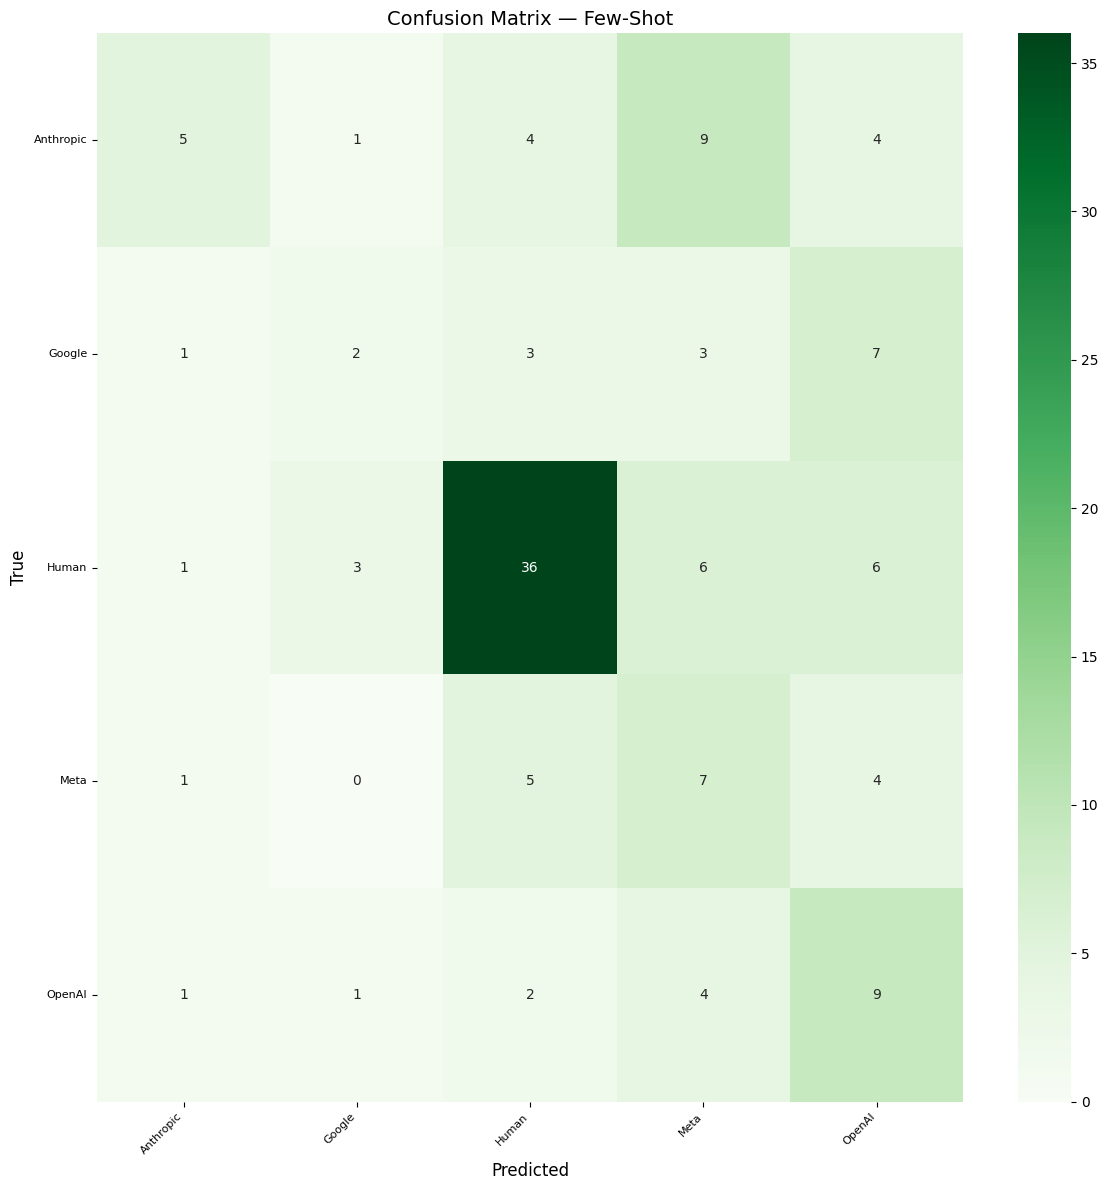

Saved → confusion_matrix_fewshot.png


In [16]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
present_labels = sorted(set(y_true + y_pred))
cm = confusion_matrix(y_true, y_pred, labels=present_labels)

fig_size = max(12, len(present_labels) * 0.6)
fig, ax = plt.subplots(figsize=(fig_size, fig_size))
sns.heatmap(
    cm,
    annot=True, fmt="d", cmap="Greens",
    xticklabels=present_labels,
    yticklabels=present_labels,
    ax=ax,
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title("Confusion Matrix — Few-Shot", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("confusion_matrix_fewshot.png", dpi=150)
plt.show()
print("Saved → confusion_matrix_fewshot.png")

In [ ]:
# ── Per-label F1 breakdown ────────────────────────────────────────────────────
report_raw = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
per_label = (
    pd.DataFrame(report_raw)
    .T
    .drop(["accuracy", "macro avg", "weighted avg"], errors="ignore")
    .sort_values("f1-score")
)

print("\nWorst-performing labels (lowest F1):")
print(per_label.head(10).to_string())
print("\nBest-performing labels (highest F1):")
print(per_label.tail(10).to_string())


🔴 Worst-performing labels (lowest F1):
           precision    recall  f1-score  support
Google      0.285714  0.125000  0.173913     16.0
Meta        0.241379  0.411765  0.304348     17.0
Anthropic   0.555556  0.217391  0.312500     23.0
OpenAI      0.300000  0.529412  0.382979     17.0
Human       0.720000  0.692308  0.705882     52.0

🟢 Best-performing labels (highest F1):
           precision    recall  f1-score  support
Google      0.285714  0.125000  0.173913     16.0
Meta        0.241379  0.411765  0.304348     17.0
Anthropic   0.555556  0.217391  0.312500     23.0
OpenAI      0.300000  0.529412  0.382979     17.0
Human       0.720000  0.692308  0.705882     52.0


In [ ]:
# ── Side-by-side comparison: few-shot vs zero-shot on eval set ────────────────
# (Only works if you also ran the zero-shot notebook's evaluation section)
try:
    zs_eval_path = "eval_zeroshot_results.csv"  # saved manually or load from memory
    raise FileNotFoundError  # remove this line if you have the zero-shot eval saved
except FileNotFoundError:
    print("To compare with zero-shot, save eval_results from that notebook as 'eval_zeroshot_results.csv'")
    print(f"\nFew-Shot summary: Accuracy = {acc:.2%}")

# Save eval results for potential comparison
eval_results.to_csv("eval_fewshot_results.csv", sep=";", index=False)
print("Saved eval results → eval_fewshot_results.csv")

ℹ️  To compare with zero-shot, save eval_results from that notebook as 'eval_zeroshot_results.csv'

📊 Few-Shot summary: Accuracy = 47.20%
Saved eval results → eval_fewshot_results.csv


In [19]:
# ── Show errors for manual inspection ─────────────────────────────────────────
wrong = eval_results[eval_results["True"] != eval_results["Pred_snapped"]].copy()
wrong = wrong.merge(eval_df[["ID", "Text"]], on="ID", how="left")
wrong["Text_preview"] = wrong["Text"].str[:120]

print(f"Wrong predictions: {len(wrong)} / {len(eval_results)}")
wrong[["ID", "True", "Pred_snapped", "Text_preview"]].head(20)

Wrong predictions: 66 / 125


,ID,True,Pred_snapped,Text_preview
0,D1-2,Meta,OpenAI,"PET scanning, or Positron Emission Tomography,..."
1,D1-3,Google,Human,Positron Emission Tomography (PET) scanning is...
2,D1-6,Google,OpenAI,"Vitamin D is far more than just a vitamin, it’..."
3,D1-10,Human,OpenAI,"Within 50 million years, the pressure and dens..."
4,D1-11,Meta,OpenAI,The probability of extraterrestrial life is fu...
5,D1-13,Google,OpenAI,The possibility of extraterrestrial life is on...
6,D1-14,Google,Meta,Type 1 and Type 2 diabetes are distinct condit...
7,D1-16,OpenAI,Meta,Quarks and gluons are both fundamental particl...
8,D1-19,Google,OpenAI,Spermidine is a naturally occurring polyamine ...
9,D1-20,Anthropic,Human,The probability of extraterrestrial life exist...
